# E14 — Tabular Foundation Models vs Your Boosting Model

> **Enrichment — not examinable.** The official unit content is in `examples/`. This lesson exists to connect what you just learned to how the field works in 2026.

## 📚 Learning Objectives

By completing this notebook, you will:
- Rebuild the exact boosting comparison from `examples/02_boosting.ipynb` and **measure the thing that lesson
  deliberately left unmeasured**: how much its tuning actually bought over plain defaults
- Run a 20-draw randomized hyperparameter search, then re-measure the gain on five different train/test
  splits — and find a gain too small for any single split to establish, yet consistent enough across
  re-splits to be real: the difference between "not measurable here" and "not there"
- Test the 2022 "trees beat deep learning on tabular data" claim in miniature, on your own data
- Find the regime where your gradient-boosted tree is genuinely weak — **small training sets** — by measuring
  accuracy against training-set size
- Read the published 2025–2026 tabular-foundation-model results as a clearly labelled **read-only**
  comparison, understand exactly why they cannot be reproduced on a classroom laptop, and know what a fair
  comparison would have to include

## 🔗 Where this fits

**Builds on:** Unit 5 lesson 02 `examples/02_boosting.ipynb` — same dataset, same 20,000-row sample, same
`random_state=73` split, so the Random Forest and XGBoost numbers below reproduce that lesson exactly. That
lesson prints an honest disclaimer: *"no untuned boosting baseline is trained here, so this notebook does not
itself measure how much this tuning helped."* **This notebook supplies the missing measurement.** It also
builds on Unit 5 lesson 01 `examples/01_grid_search.ipynb` (the randomized search in Part 2 is that lesson's
`RandomizedSearchCV`) and Unit 2 lesson 01 `../../unit2-regression-model-evaluation/examples/01_cross_validation.ipynb`
(one split gives one lucky number — Part 2b is that argument applied to a tuning result).

**Used later in:** Course 05 (AIAT 115) Unit 4 lesson 08
`Course 05/unit4-ml-intro/examples/08_hyperparameter_tuning_grid_random_search.ipynb`, and Course 12
(AIAT 126) Unit 3 lesson 02 `Course 12/unit3-model-development/examples/02_model_training_hyperparameter_optimization.ipynb`,
where your graduation project has to justify how much time it spent tuning.

**Honest structure of this lesson.** Parts 1–4 **run on your machine, offline, on CPU**. Part 5 is
**read-only**: it reports published numbers you cannot reproduce here, and says exactly why. The two halves
are never mixed in the same chart or the same table.

## 🌍 A real case: the same researcher, on both sides of the argument

In 2022, **Léo Grinsztajn, Edouard Oyallon and Gaël Varoquaux** published *"Why do tree-based models still
outperform deep learning on tabular data?"* ([arXiv:2207.08815](https://arxiv.org/abs/2207.08815)). They
assembled a standard set of **45 datasets** from varied domains and spent **20,000 compute hours of
hyperparameter search per learner** to make the comparison fair. Their finding: tree-based models remain
state of the art on medium-sized data (~10K samples), because neural networks struggle to be robust to
uninformative features, to preserve the orientation of the data, and to learn irregular functions. That
paper is the reason your instructor can tell you, honestly, that XGBoost is the right first thing to try.

Three years later the **first author of that paper is the first author of TabPFN-2.5**
([arXiv:2511.08667](https://arxiv.org/abs/2511.08667), Nov 2025) and of **TabPFN-3**
([arXiv:2605.13986](https://arxiv.org/abs/2605.13986), May 2026) — a family of *pretrained transformers* that
make tabular predictions **in-context**, with no per-dataset training and no hyperparameter tuning at all.
TabPFN-2.5 reports a **100% win rate against default XGBoost** on classification datasets of up to 10,000
rows and 500 features.

The same person, with the same standards, on both sides. That is not a contradiction — it is what a field
moving looks like, and it is the most honest possible reason to take the claim seriously and to check it
carefully.

**❗ Why this lesson exists.** Unit 5 teaches you to tune a boosting model, and tuning is the single most
time-consuming habit you will carry out of this course. Before you spend that time on every project for the
rest of your career, it is worth measuring what it actually buys you — and knowing that in 2026 there is a
competitor whose entire pitch is *"do not tune anything."* Neither fact changes what this unit examines.
Both change how you would start a real project.

## 📥 Inputs & 📤 Outputs

**Inputs:** `load("montgomery_911_calls", prefer="sample")` — real emergency calls from Montgomery County,
Pennsylvania. You write no file path: the loader finds the data from any working directory and downloads it
on Google Colab. Like Unit 5 lesson 02, this notebook reads the **25,000-row extract that ships with the
repository** (1 call in every 27, still spanning 2015–2020) and draws the **same 20,000-row sample with the
same seed (73)**, the same six features (`lat`, `lng`, `zip`, `hour`, `day_of_week`, `month`) and the same
3-class target (EMS / Fire / Traffic). Part 1 therefore reproduces that lesson's accuracies to the last
decimal — check them against it. The 663,522-row original is not needed: no downloads, no network, no GPU.

**Outputs:** a four-model accuracy table that reproduces lesson 02; the wall-clock cost and the accuracy gain
of a 20-draw randomized search; that same gain re-measured across five independent splits with its standard
deviation; a neural network compared against the tree on identical data; an accuracy-versus-training-size
curve for three model families with a majority-class floor drawn on it; and a clearly labelled read-only
chart of published tabular-foundation-model results.

**Runtime:** 30-45 seconds on a laptop CPU for the runnable half. Part 5 computes nothing.

## Part 1: Rebuild the Model You Already Have

Nothing new here — this is lesson 02's setup, re-executed, plus **one model that lesson did not train**:
XGBoost with its out-of-the-box defaults. That missing baseline is what turns "we tuned it" into a
measurable claim.

In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root, put it on sys.path, then import the shared data loader.
# WHY:  a hard-coded relative path such as ../../datasets/raw/<file>.csv only resolves when
#       the kernel's working directory happens to be this notebook's folder. Open it from the
#       repository root, from JupyterLab at another level, or on Colab where there is no
#       repository at all, and it breaks. load() finds the data wherever you are, downloads
#       it if this machine has none, and says out loud which copy it used.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud", prefer="sample"), ...
# -------------------------------------------------------------------------------------
print("Data loader ready - no file paths needed, and this works on Colab too.")


Data loader ready - no file paths needed, and this works on Colab too.


In [2]:
# WHAT: load the 911-calls file and rebuild exactly the sample, features and split used by
#       examples/02_boosting.ipynb (20,000 rows, seed 73, six features, three classes).
# WHY:  a comparison is only meaningful against numbers the reader already has. Reproducing that lesson's
#       split bit-for-bit means any difference you see below comes from the MODEL, not from the data.
# WHY load(..., prefer="sample"): lesson 02 reads the 25,000-row extract that ships inside the
#       repository (1 call in every 27, evenly spread, still spanning 2015-2020 with all 100 call
#       types). Reading the same copy the same way is what makes "bit-for-bit" true - and it is why
#       this notebook needs no download and no file path on any machine.
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

full = load("montgomery_911_calls", prefer="sample",
            usecols=["lat", "lng", "zip", "title", "timeStamp"])
if len(full) < 20_000:
    raise RuntimeError(
        f"Expected at least 20,000 call records, found {len(full):,}. "
        "See Course 04/datasets/DATA.md.")

sample = full.sample(n=20_000, random_state=73).copy()          # lesson 02's sample, same seed
sample["category"] = sample["title"].str.split(":").str[0]      # 'EMS: BACK PAINS/INJURY' -> 'EMS'
encoder = LabelEncoder()
y = encoder.fit_transform(sample["category"])

stamp = pd.to_datetime(sample["timeStamp"], errors="coerce")
sample["hour"] = stamp.dt.hour
sample["day_of_week"] = stamp.dt.dayofweek
sample["month"] = stamp.dt.month

FEATURES = ["lat", "lng", "zip", "hour", "day_of_week", "month"]
X = sample[FEATURES].copy()
X = X.fillna(X.median())                                        # zip is sometimes blank in the raw file

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=73, stratify=y)

majority_rate = float((y_test == np.bincount(y_train).argmax()).mean())
print(f"Calls in the copy loaded : {len(full):,}   sampled: {len(sample):,}")
print(f"Classes       : {list(encoder.classes_)}   counts {np.bincount(y).tolist()}")
print(f"Split         : {len(X_train):,} train / {len(X_test):,} test")
print(f"Majority-class floor on the test set: {majority_rate:.4f}  "
      f"(always answer '{encoder.classes_[np.bincount(y_train).argmax()]}')")


montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
Calls in the copy loaded : 25,000   sampled: 20,000
Classes       : ['EMS', 'Fire', 'Traffic']   counts [10089, 2981, 6930]
Split         : 16,000 train / 4,000 test
Majority-class floor on the test set: 0.5045  (always answer 'EMS')


In [3]:
# WHAT: train lesson 02's two models, then the one it never trained — XGBoost with pure defaults.
# WHY:  "we used tuned parameters" is a claim, and a claim without a baseline is untestable. The default
#       model costs one line and is the only honest reference point for any tuning result.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb

results = {}

t0 = time.time()
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=73).fit(X_train, y_train)
results["Random Forest (lesson 02)"] = (accuracy_score(y_test, rf.predict(X_test)), time.time() - t0)

t0 = time.time()
xgb_lesson = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=73, eval_metric="logloss").fit(X_train, y_train)
results["XGBoost, lesson 02's 'tuned' settings"] = (
    accuracy_score(y_test, xgb_lesson.predict(X_test)), time.time() - t0)

t0 = time.time()
xgb_default = xgb.XGBClassifier(random_state=73, eval_metric="logloss").fit(X_train, y_train)
results["XGBoost, out-of-the-box defaults"] = (
    accuracy_score(y_test, xgb_default.predict(X_test)), time.time() - t0)

table = pd.DataFrame([{"model": k, "test accuracy": v[0], "fit seconds": v[1]}
                      for k, v in results.items()])
print(table.to_string(index=False, formatters={"test accuracy": "{:.4f}".format,
                                               "fit seconds": "{:.2f}".format}))
print(f"\nTrain accuracy of the 'tuned' XGBoost: "
      f"{accuracy_score(y_train, xgb_lesson.predict(X_train)):.4f}  "
      "(lesson 02 reports the same gap)")

# The verdict is COMPUTED, not asserted, so it can never disagree with the table above.
acc_hand = results["XGBoost, lesson 02's 'tuned' settings"][0]
acc_box = results["XGBoost, out-of-the-box defaults"][0]
se_test = float(np.sqrt(acc_box * (1 - acc_box) / len(y_test)))
print(f"\nRead the middle two rows together. The hand-picked 'tuned' settings scored {acc_hand:.4f} and the")
print(f"out-of-the-box defaults scored {acc_box:.4f}: a difference of {100 * (acc_hand - acc_box):+.2f} percentage points,")
print(f"against a standard error of {100 * se_test:.2f} points on {len(y_test):,} test rows.")
print("Hand-picking those six numbers bought nothing this test set can measure. Whatever value tuning")
print("has, it is not in guessing parameters by hand - which is why Part 2 runs an actual search.")

                                model test accuracy fit seconds
            Random Forest (lesson 02)        0.5290        0.38
XGBoost, lesson 02's 'tuned' settings        0.5710        0.76
     XGBoost, out-of-the-box defaults        0.5693        0.37

Train accuracy of the 'tuned' XGBoost: 0.6508  (lesson 02 reports the same gap)

Read the middle two rows together. The hand-picked 'tuned' settings scored 0.5710 and the
out-of-the-box defaults scored 0.5693: a difference of +0.17 percentage points,
against a standard error of 0.78 points on 4,000 test rows.
Hand-picking those six numbers bought nothing this test set can measure. Whatever value tuning
has, it is not in guessing parameters by hand - which is why Part 2 runs an actual search.


## Part 2: The Experiment — What Does Tuning Actually Buy?

**Baseline:** XGBoost with its defaults, from Part 1.

**Change exactly one thing:** run Unit 5 lesson 01's `RandomizedSearchCV` — 20 random draws from a
six-dimensional hyperparameter space, each scored by 3-fold cross-validation on the *training* rows only.
The test set is not consulted while choosing.

**Re-run and state the conclusion the numbers support.** That is the entire method of this unit, applied to
the unit itself.

In [4]:
# WHAT: 20 random hyperparameter draws, 3-fold CV, selected on training data only.
# WHY:  this is the honest version of tuning: the search never sees the test set, so the test score
#       afterwards is an unbiased estimate of what the tuned model is worth. Wall-clock time is recorded
#       because time is the resource tuning actually spends.
from sklearn.model_selection import RandomizedSearchCV

search_space = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.02, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [0.5, 1.0, 5.0],
}

t0 = time.time()
search = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=73, eval_metric="logloss", n_jobs=1),
    search_space, n_iter=20, cv=3, scoring="accuracy", random_state=73, n_jobs=-1,
).fit(X_train, y_train)
search_seconds = time.time() - t0

acc_default = results["XGBoost, out-of-the-box defaults"][0]
acc_searched = accuracy_score(y_test, search.predict(X_test))

print(f"20 draws x 3 folds = 60 model fits, in {search_seconds:.1f} seconds")
print(f"best cross-validated accuracy on the training rows : {search.best_score_:.4f}")
print(f"best parameters found: {search.best_params_}\n")
print(f"BASELINE  XGBoost defaults        test accuracy = {acc_default:.4f}")
print(f"CHANGED   after a 20-draw search  test accuracy = {acc_searched:.4f}")
print(f"                                  difference    = {acc_searched - acc_default:+.4f} "
      f"({100 * (acc_searched - acc_default):+.2f} percentage points)")
print(f"\nStandard error of an accuracy estimate on {len(y_test):,} test rows: "
      f"{np.sqrt(acc_default * (1 - acc_default) / len(y_test)):.4f}")

20 draws x 3 folds = 60 model fits, in 3.8 seconds
best cross-validated accuracy on the training rows : 0.5764
best parameters found: {'subsample': 1.0, 'reg_lambda': 1.0, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.6}

BASELINE  XGBoost defaults        test accuracy = 0.5693
CHANGED   after a 20-draw search  test accuracy = 0.5767
                                  difference    = +0.0075 (+0.75 percentage points)

Standard error of an accuracy estimate on 4,000 test rows: 0.0078


### Part 2b: Is That Gain Real?

A gain smaller than the standard error of the measurement is not a gain you have observed — it is a gain you
have *failed to rule out*. Unit 2 lesson 01 made exactly this argument about single splits. Apply it here:
refit both models — defaults, and the parameters the search chose — on **five independent train/test
splits** and look at the distribution of the difference rather than at one number.

In [5]:
# WHAT: repeat the default-vs-searched comparison on five different random splits of the same 20,000 rows.
# WHY:  one split gives one lucky number (Unit 2, lesson 01). A tuning gain worth believing has to be
#       larger than the spread you get by re-shuffling the data. Here we can see whether it is.
best_params = search.best_params_
rows = []
t0 = time.time()
for seed in (11, 23, 37, 73, 101):
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    m_default = xgb.XGBClassifier(random_state=73, eval_metric="logloss").fit(Xa, ya)
    m_tuned = xgb.XGBClassifier(random_state=73, eval_metric="logloss", **best_params).fit(Xa, ya)
    rows.append({"split seed": seed,
                 "defaults": accuracy_score(yb, m_default.predict(Xb)),
                 "searched params": accuracy_score(yb, m_tuned.predict(Xb))})

repeat = pd.DataFrame(rows)
repeat["difference"] = repeat["searched params"] - repeat["defaults"]
print(repeat.to_string(index=False, formatters={c: "{:+.4f}".format if c == "difference"
                                                else "{:.4f}".format
                                                for c in ["defaults", "searched params", "difference"]}))
diff = repeat["difference"]
# Describe the sign pattern from the numbers themselves, so the sentence cannot go stale.
sign_note = ("the sign flips across splits" if (diff > 0).any() and (diff < 0).any()
             else f"the sign is the same on all {len(diff)} splits")
print(f"\ndefaults        : {repeat['defaults'].mean():.4f} +/- {repeat['defaults'].std(ddof=1):.4f}")
print(f"searched params : {repeat['searched params'].mean():.4f} +/- "
      f"{repeat['searched params'].std(ddof=1):.4f}")
print(f"mean difference : {diff.mean():+.4f}  (sd {diff.std(ddof=1):.4f}, {sign_note})")
print(f"\nCost of that difference: {search_seconds:.1f} seconds of search. Measured over five splits in "
      f"{time.time() - t0:.1f} seconds.")
print("\nCONCLUSION the numbers support: on THIS dataset, with THESE six features, a 20-draw randomized")
print(f"search moved test accuracy by {100 * diff.mean():+.2f} percentage points on average, and {sign_note}.")
print(f"That average is smaller than the {100 * se_test:.2f}-point standard error of a single split's accuracy,")
print("so no ONE split could ever have established it -- yet re-measuring on five splits shows it is not")
print("zero either. The honest reading is: a real gain, too small for one experiment to see, bought for")
print(f"{search_seconds:.0f} seconds. Worth {search_seconds:.0f} seconds; not worth a week. And one dataset proves nothing in")
print("general -- which is precisely why Grinsztajn et al. needed 45 datasets and 20,000 compute hours.")

 split seed defaults searched params difference
         11   0.5817          0.5847    +0.0030
         23   0.5835          0.5960    +0.0125
         37   0.5763          0.5853    +0.0090
         73   0.5693          0.5767    +0.0075
        101   0.5750          0.5787    +0.0038

defaults        : 0.5771 +/- 0.0057
searched params : 0.5843 +/- 0.0075
mean difference : +0.0071  (sd 0.0039, the sign is the same on all 5 splits)

Cost of that difference: 3.8 seconds of search. Measured over five splits in 11.5 seconds.

CONCLUSION the numbers support: on THIS dataset, with THESE six features, a 20-draw randomized
search moved test accuracy by +0.71 percentage points on average, and the sign is the same on all 5 splits.
That average is smaller than the 0.78-point standard error of a single split's accuracy,
so no ONE split could ever have established it -- yet re-measuring on five splits shows it is not
zero either. The honest reading is: a real gain, too small for one experiment t

## Part 3: Does a Neural Network Beat It? (Grinsztajn et al. 2022, in Miniature)

The 2022 paper's claim is that on medium-sized tabular data, tree ensembles beat neural networks. You can
test the *shape* of that claim on your own data in five seconds: a two-hidden-layer MLP on standardized
features, a logistic regression, and the majority-class floor, against the same boosted tree.

This is an **illustration, not evidence**. One dataset, one architecture, no tuning of the network. Read
Part 4's caveat before you quote it at anyone.

In [6]:
# WHAT: put a neural network, a linear model and the majority-class floor next to the boosted tree.
# WHY:  scaling matters enormously for the MLP and not at all for the tree — that asymmetry is half of
#       why trees are the default on tabular data. The majority-class row is there to stop us calling
#       0.51 accuracy "a model".
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

contenders = {}

t0 = time.time()
mlp = make_pipeline(StandardScaler(),
                    MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
                                  early_stopping=True, random_state=73)).fit(X_train, y_train)
contenders["MLP (128, 64), standardized"] = (accuracy_score(y_test, mlp.predict(X_test)), time.time() - t0)

t0 = time.time()
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_train, y_train)
contenders["Logistic regression"] = (accuracy_score(y_test, logreg.predict(X_test)), time.time() - t0)

contenders["XGBoost defaults"] = (acc_default, results["XGBoost, out-of-the-box defaults"][1])
contenders["Majority class (no model)"] = (majority_rate, 0.0)

compare = pd.DataFrame([{"model": k, "test accuracy": v[0], "fit seconds": v[1]}
                        for k, v in contenders.items()]).sort_values("test accuracy", ascending=False)
print(compare.to_string(index=False, formatters={"test accuracy": "{:.4f}".format,
                                                 "fit seconds": "{:.2f}".format}))
print(f"\nGap between the tree and the network: "
      f"{contenders['XGBoost defaults'][0] - contenders['MLP (128, 64), standardized'][0]:+.4f}")
print("Note where the linear model and the network sit relative to 'always guess the biggest class'.")

                      model test accuracy fit seconds
           XGBoost defaults        0.5693        0.37
MLP (128, 64), standardized        0.5142        0.33
  Majority class (no model)        0.5045        0.00
        Logistic regression        0.5042        0.01

Gap between the tree and the network: +0.0550
Note where the linear model and the network sit relative to 'always guess the biggest class'.


## Part 4: Where Your Boosting Model Is Actually Weak

Everything so far used all 16,000 training rows. Most real tabular problems do not have 16,000 labelled
rows — they have a few hundred, because someone had to label them by hand.

Hold the test set fixed, shrink the *training* set, and watch what happens. This is the experiment that
tells you which claim about tabular foundation models is worth your attention, because their entire pitch
lives in the left-hand side of this chart.

In [7]:
# WHAT: accuracy against training-set size for three model families, three random subsamples each.
# WHY:  this is a learning curve (Unit 2, lesson 02) used as a diagnostic of REGIME rather than of fit.
#       np.random appears here only to choose which rows to keep — the data itself is entirely real.
sizes = [200, 500, 1000, 2000, 5000, 16000]
curve_rows = []

t0 = time.time()
for n in sizes:
    scores = {"XGBoost": [], "MLP": [], "Logistic regression": []}
    for seed in (0, 1, 2):                                  # three subsamples, so each point is an average
        idx = np.random.default_rng(seed).choice(len(X_train), n, replace=False)
        Xs, ys = X_train.iloc[idx], y_train[idx]
        scores["XGBoost"].append(accuracy_score(
            y_test, xgb.XGBClassifier(random_state=73, eval_metric="logloss").fit(Xs, ys).predict(X_test)))
        scores["MLP"].append(accuracy_score(y_test, make_pipeline(
            StandardScaler(), MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
                                            early_stopping=True, random_state=73)
        ).fit(Xs, ys).predict(X_test)))
        scores["Logistic regression"].append(accuracy_score(y_test, make_pipeline(
            StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xs, ys).predict(X_test)))
    curve_rows.append({"training rows": n, **{k: float(np.mean(v)) for k, v in scores.items()}})

curve = pd.DataFrame(curve_rows)
print(curve.to_string(index=False, formatters={c: "{:.4f}".format for c in
                                               ["XGBoost", "MLP", "Logistic regression"]}))
print(f"\nmajority-class floor: {majority_rate:.4f}   (computed in {time.time() - t0:.1f}s)")

 training rows XGBoost    MLP Logistic regression
           200  0.4507 0.4522              0.4792
           500  0.4671 0.4966              0.4912
          1000  0.4857 0.4992              0.4977
          2000  0.5087 0.4965              0.4995
          5000  0.5323 0.5046              0.5039
         16000  0.5698 0.5122              0.5042

majority-class floor: 0.5045   (computed in 9.8s)


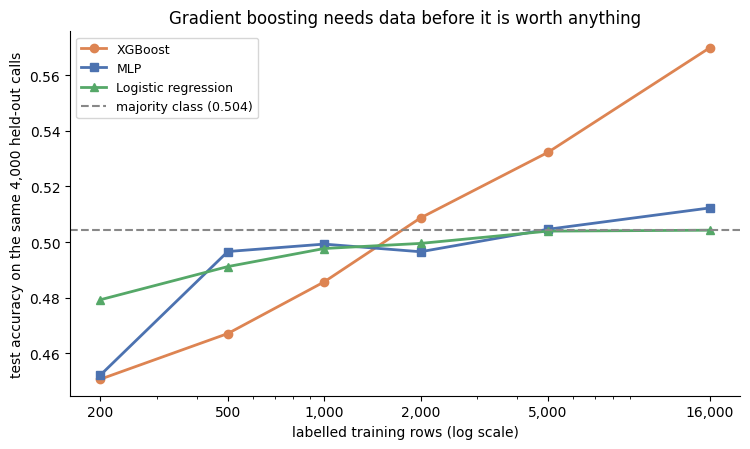

At 200 training rows XGBoost scores 0.4507 — below the majority-class floor of 0.5045.
At 16,000 rows it scores 0.5698 and wins comfortably.

The left-hand side of this chart is the entire market for tabular foundation models.


In [8]:
# WHAT: plot the same table, with the majority-class floor drawn as the line every model must clear.
# WHY:  the crossing points are the result. Where a curve sits below the dashed line, that model has
#       learned nothing you could not get by answering 'EMS' to every call.
import matplotlib.pyplot as plt   # the ai-diploma kernel renders figures inline; no window is opened

fig, ax = plt.subplots(figsize=(7.6, 4.6))
styles = {"XGBoost": ("o-", "#DD8452"), "MLP": ("s-", "#4C72B0"),
          "Logistic regression": ("^-", "#55A868")}
for name, (marker, colour) in styles.items():
    ax.plot(curve["training rows"], curve[name], marker, color=colour, lw=2, label=name)
ax.axhline(majority_rate, ls="--", color="#888", lw=1.5,
           label=f"majority class ({majority_rate:.3f})")
ax.set_xscale("log")
ax.set_xticks(sizes, [f"{n:,}" for n in sizes])
ax.set_xlabel("labelled training rows (log scale)")
ax.set_ylabel("test accuracy on the same 4,000 held-out calls")
ax.set_title("Gradient boosting needs data before it is worth anything")
ax.legend(loc="upper left", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

small, large = curve.iloc[0], curve.iloc[-1]
print(f"At {int(small['training rows']):,} training rows XGBoost scores {small['XGBoost']:.4f} — "
      f"below the majority-class floor of {majority_rate:.4f}.")
print(f"At {int(large['training rows']):,} rows it scores {large['XGBoost']:.4f} and wins comfortably.")
print("\nThe left-hand side of this chart is the entire market for tabular foundation models.")

## 💬 Discuss

1. **Part 2b found a tuning gain of +0.71 percentage points — positive on every one of five splits, but
   smaller than the ±0.78-point standard error of any single split's accuracy — after 60 model fits.** A
   result no single experiment could have detected, and under four seconds of search to buy. Does that mean you should keep
   tuning, or stop? Write the rule you would actually follow on a new project — including how you
   would decide *before* the search whether the search is worth running at all. Then say what would have to
   be true of a dataset for your rule to give the opposite answer.

2. **Look at the left-hand end of the Part 4 chart: at 200 labelled rows nothing beats guessing** — XGBoost
   scores 0.4507 and logistic regression 0.4792, both under the 0.5045 majority-class floor. A client
   has 300 labelled rows and a budget. They can pay for (a) 3,000 more labels, (b) a month of your time on
   feature engineering, or (c) a tabular foundation model they cannot inspect and whose weights live on
   someone else's server. Rank those three, and name the piece of information you would need before your
   ranking could change.

3. **TabPFN-2.5 reports a 100% win rate against default XGBoost below 10,000 rows.** A win rate counts
   datasets, not margins — a 100% win rate is compatible with every win being a tenth of a percentage point.
   What *additional* number would you insist on seeing before you let a 100% win rate change your default
   choice of model, and why is that number the one that matters?

## Part 5 — READ-ONLY: What the 2025–2026 Tabular Foundation Models Report

> ### ⛔ Nothing in this section runs on your machine, and nothing in it was measured by this notebook.
> Every figure below is **quoted from the paper that reported it**, with its arXiv identifier attached so
> you can check it yourself. Treat it exactly as you would treat a vendor's benchmark page: as a claim,
> made by interested parties, that has an address.

**Why this half cannot run here.** TabPFN is not an algorithm you fit — it is a *pretrained transformer*.
The knowledge is in the weights, and the weights (hundreds of megabytes to gigabytes) must be downloaded
before the first prediction. There is no training step to run locally, no CPU-only substitute that would
tell you anything about the real model, and the package is not installed in this environment. A lesson that
pretended otherwise would be lying about the thing it was teaching. So: published numbers, clearly labelled.

**What the papers report**

| Model | Year · id | Regime it claims | Headline result *as reported by its authors* |
|---|---|---|---|
| **TabPFN** (v1) | 2022 · [2207.01848](https://arxiv.org/abs/2207.01848) | ≤ 1,000 training rows, ≤ 100 numerical features, ≤ 10 classes | "clearly outperforms boosted trees" on the 18 OpenML-CC18 datasets in that regime; on par with AutoML at up to **230× speedup** (**5,700×** on GPU); a prediction in **under one second** |
| **TabPFN-2.5** | 2025 · [2511.08667](https://arxiv.org/abs/2511.08667) | up to 50,000 rows and 2,000 features | **100% win rate against default XGBoost** on classification ≤ 10,000 rows / 500 features; **87%** on larger datasets up to 100K × 2K (**85%** for regression); "matching the accuracy of AutoGluon 1.4, a complex four-hour tuned ensemble" |
| **TabPFN-3** | 2026 · [2605.13986](https://arxiv.org/abs/2605.13986) | up to 1M training rows, 200 features | TabPFN-3-Plus beats non-TabPFN models by **over 200 Elo on TabArena**, rising to **420 Elo** on the largest data subset; **10× faster** than AutoGluon 1.5 extreme and **20× faster** than TabPFN-2.5 |
| **AutoGluon-Tabular** (the yardstick) | 2020 · [2003.06505](https://arxiv.org/abs/2003.06505) | general tabular AutoML | beat **99% of participating data scientists** in two Kaggle competitions after 4 hours on raw data — this is the system the TabPFN papers measure themselves against |

**Where your own task sits.** The 20,000-row problem you just modelled is *outside* the ≤10,000-row regime
where the 100% win rate is claimed, and *inside* the "larger datasets" regime where the claim is 87%. The
left-hand end of your Part 4 chart — 200 to 2,000 rows, where your boosted tree could not clear the
majority-class floor — is squarely inside TabPFN v1's original regime.

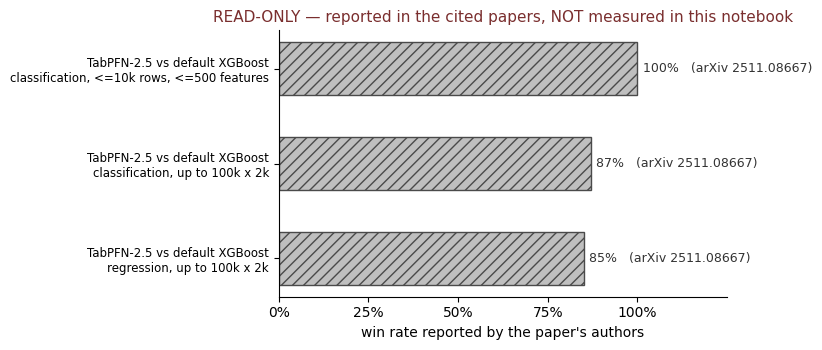

Hatched grey bars = quoted claims. Every solid-coloured chart earlier in this notebook was
computed from the 911-calls file on your own machine. Do not mix the two when you report results.


In [9]:
# WHAT: draw the published win rates as a chart that cannot be mistaken for a measurement of ours.
# WHY:  the pack asked for a read-only comparison chart, and a read-only chart has an obligation: hatched
#       bars, grey palette, the source printed on every bar, and no measured number anywhere near it.
fig, ax = plt.subplots(figsize=(8.0, 3.6))
claims = [
    ("TabPFN-2.5 vs default XGBoost\nclassification, <=10k rows, <=500 features", 1.00, "2511.08667"),
    ("TabPFN-2.5 vs default XGBoost\nclassification, up to 100k x 2k", 0.87, "2511.08667"),
    ("TabPFN-2.5 vs default XGBoost\nregression, up to 100k x 2k", 0.85, "2511.08667"),
]
labels = [c[0] for c in claims]
values = [c[1] for c in claims]
bars = ax.barh(range(len(claims)), values, color="#BFBFBF", edgecolor="#4A4A4A",
               hatch="///", height=0.55)
for i, (bar, (_, v, src)) in enumerate(zip(bars, claims)):
    ax.text(v + 0.015, i, f"{v:.0%}   (arXiv {src})", va="center", fontsize=9, color="#333")
ax.set_yticks(range(len(claims)), labels, fontsize=8.5)
ax.invert_yaxis()
ax.set_xlim(0, 1.25)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0], ["0%", "25%", "50%", "75%", "100%"])
ax.set_xlabel("win rate reported by the paper's authors")
ax.set_title("READ-ONLY — reported in the cited papers, NOT measured in this notebook",
             fontsize=11, color="#7A2E2E")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("Hatched grey bars = quoted claims. Every solid-coloured chart earlier in this notebook was")
print("computed from the 911-calls file on your own machine. Do not mix the two when you report results.")

### What to do with this, as a student

**If you want to actually run one:** TabPFN is pip-installable and runs on a machine with internet access
and, ideally, a GPU. Home study, not classroom work.

**If you want to understand one:** read **nanoTabPFN** (Pfefferle, Hog, Purucker & Hutter, 2025,
[arXiv:2511.03634](https://arxiv.org/abs/2511.03634)). Its stated motivation is that existing open tabular
foundation models are "implemented in complicated pipelines boasting over 10,000 lines of code", which makes
them impossible to learn from. nanoTabPFN is a deliberately small, educational reimplementation of the
TabPFN v2 architecture; the paper reports that in a small-data setting it reaches "performance comparable to
traditional machine learning baselines within one minute of pre-training on a single GPU (160,000× faster
than TabPFN v2 pretraining)". That is the right entry point: it is short enough to read in an afternoon, and
the point of reading it is to see that **in-context learning on tables is a transformer trained on synthetic
datasets drawn from a prior** — not magic, and not a search over hyperparameters either.

**What has not changed.** The workflow this unit taught you — hold out data, cross-validate, compare against
a stated baseline, report the number you got and not the number you hoped for — is what lets you *evaluate*
a foundation model. It is more valuable in 2026, not less, because the number of things claiming to beat
your model went up.

## ⚠️ Where this breaks

**One dataset is not a benchmark, and this notebook is one dataset.** Every runnable number above comes from
a single 20,000-row sample of 911 calls with six weak features — themselves drawn from the 25,000-row extract
of the call log that ships with this repository, not from all 663,522 calls. The tuning gain was worth
0.71 accuracy points *here*; on a dataset with strong interactions and a wider useful hyperparameter range it
would be worth more, and on a dataset whose features carry no signal it would be worth nothing. Grinsztajn et al. used 45
datasets and 20,000 compute hours per learner precisely because a single-dataset result is an anecdote. Quote
this notebook as "on this data", never as "in general".

**Our search space is small and so is our search.** Twenty draws over six hyperparameters explores a tiny
fraction of the space; a 500-draw search, or Bayesian optimization, or early-stopping with a validation set,
would all do better. "Tuning did not help" is a statement about *this* search, not about tuning.

**The neural network was not tuned and the tree effectively was.** XGBoost's defaults are the accumulated
tuning of a decade of Kaggle competitions; `MLPClassifier`'s defaults are not. A fair deep-learning
comparison needs architecture search, learning-rate scheduling and embeddings for the categorical columns.
Part 3 is an illustration of a published claim, not a replication of it.

**Published win rates are not measurements you made.** Every number in Part 5 was reported by the authors of
the model it flatters, on benchmarks whose dataset selection they participated in choosing. That does not
make them false — the papers are public and the code is largely open — but the correct posture is the one you would take toward any vendor benchmark: check the regime,
check the baseline they compared against ("default XGBoost" is a much weaker opponent than "tuned
XGBoost + AutoGluon"), and check whether the margin is reported at all.

**Foundation models move your risks rather than removing them.** No per-dataset training means no
per-dataset overfitting — but it also means the model's inductive bias came from a synthetic prior chosen by
someone else, your data must leave your machine or a large binary must enter it, the weights can be updated
under you, and interpretability tooling has to be rebuilt (which is why *Real-Time Explanations for Tabular
Foundation Models*, arXiv 2603.29946, exists). For a bank or a hospital those are governance problems, not
accuracy problems, and they are decided in Course 06 and Course 12, not here.

**"No tuning" is not "no choices".** You still choose the features, the target, the split, the metric and the
threshold. Every failure mode this course taught you about — leakage, an unrepresentative split, a metric
that does not match the decision — survives a foundation model completely intact.

## ✅ Summary

**What you measured** (all on the same 4,000 held-out 911 calls, offline, on CPU):

- Reproduced lesson 02 exactly: Random Forest **0.5290**, XGBoost with its "tuned" settings **0.5710** —
  the same figures that lesson prints, because both read the same bundled extract and take the same seed-73 sample
- Trained the baseline that lesson omitted: **XGBoost with pure defaults scored 0.5693** — **+0.17 points**
  *below* the hand-picked settings, against a **0.78**-point standard error: hand-picking bought nothing measurable
- Ran a 20-draw randomized search (60 fits, under 4 s) and reached **0.5767** on the test set: **+0.75 percentage
  points** over defaults, still inside that same **0.78**-point standard error
- Re-measured that gain across five splits: defaults **0.5771 ± 0.0057**, searched parameters
  **0.5843 ± 0.0075**, mean difference **+0.0071** with the **same sign on all five splits** — **a real gain,
  too small for any one split to have established, bought for under four seconds**
- Compared model families: XGBoost **0.5693**, MLP **0.5142**, logistic regression **0.5042**, majority class
  **0.5045** — the tree beats the network by **5.5 points**, while the network clears the no-model floor by
  one point and the linear model does not clear it at all
- Traced accuracy against training size: at **200** rows XGBoost scores **0.4507**, *below* the majority-class
  floor; it only pulls clear at **5,000** rows (**0.5323**) and reaches **0.5698** at 16,000

**The one sentence to keep:** your boosted tree's weakness is not its accuracy on big tables, it is its
helplessness on small ones — and that is precisely the gap a pretrained tabular model claims to fill, which
is why "benchmark against a foundation-model baseline before you tune" is a reasonable 2026 first step and
"stop teaching gradient boosting" is not.

**Not examinable.** Unit 5's CLOs are grid search, random search, XGBoost, LightGBM and a defensible model
selection procedure. Every one of them is exercised above; none of them is replaced.

## 📚 References

Verified citations — title, authors and reported figures were read from each paper's arXiv abstract page.

1. Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). *Why do tree-based models still outperform deep
   learning on tabular data?* [arXiv:2207.08815](https://arxiv.org/abs/2207.08815) — 45 datasets, 20,000
   compute hours of hyperparameter search per learner; the honest baseline result behind Part 3.
2. Hollmann, N., Müller, S., Eggensperger, K., & Hutter, F. (2022, rev. 2023). *TabPFN: A Transformer That
   Solves Small Tabular Classification Problems in a Second*.
   [arXiv:2207.01848](https://arxiv.org/abs/2207.01848) — the origin of in-context learning for tables;
   its stated regime (≤1,000 rows) is the left-hand end of the Part 4 chart.
3. Grinsztajn, L., Flöge, K., Key, O., Birkel, F., Jund, P., et al. (2025, rev. 2026). *TabPFN-2.5:
   Advancing the State of the Art in Tabular Foundation Models*.
   [arXiv:2511.08667](https://arxiv.org/abs/2511.08667) — the 100% / 87% / 85% win rates quoted in Part 5.
4. Grinsztajn, L., Flöge, K., Key, O., Birkel, F., Jund, P., et al. (2026). *TabPFN-3: Technical Report*.
   [arXiv:2605.13986](https://arxiv.org/abs/2605.13986) — scaling to 1M training rows; the Elo and speed
   figures quoted in Part 5.
5. Pfefferle, A., Hog, J., Purucker, L., & Hutter, F. (2025). *nanoTabPFN: A Lightweight and Educational
   Reimplementation of TabPFN*. [arXiv:2511.03634](https://arxiv.org/abs/2511.03634) — the recommended home
   study for anyone who wants to understand rather than merely call one.
6. Erickson, N., Mueller, J., Shirkov, A., Zhang, H., Larroy, P., Li, M., & Smola, A. (2020).
   *AutoGluon-Tabular: Robust and Accurate AutoML for Structured Data*.
   [arXiv:2003.06505](https://arxiv.org/abs/2003.06505) — the AutoML yardstick the TabPFN papers measure
   against.
7. Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD 2016.
   [arXiv:1603.02754](https://arxiv.org/abs/1603.02754) — the model you tuned in `examples/02_boosting.ipynb`
   and the baseline every claim in Part 5 is measured against.
8. Sena, L. B. T. R., & Azevedo, F. G. (2026). *Real-Time Explanations for Tabular Foundation Models*.
   [arXiv:2603.29946](https://arxiv.org/abs/2603.29946) — interpretability rebuilt inside the model, for the
   governance problem named in "Where this breaks".
9. Montgomery County, Pennsylvania. *Emergency (911) Calls: Fire, Traffic, EMS* — the dataset used here,
   read with `load("montgomery_911_calls", prefer="sample")`; the 25,000-row extract ships in the repository
   and the 663,522-row original is on Kaggle as `mchirico/montcoalert`. See `Course 04/datasets/DATA.md`.